# Project Title - Edit Me


## Data set selection

> In this section, you will need to provide the following information about the selected data set:
>
> - Source with a link
>   - Stack Overflow. Stack Overflow Developer Survey 2025.
>   - https://survey.stackoverflow.co/
> - Fields
>   - ResponseId, MainBranch, Age, EdLevel, Employment, EmploymentAddl, WorkExp, LearnCodeChoose, LearnCode, LearnCodeAI, …, AIAgentOrchestration, AIAgentOrchWrite, AIAgentObserveSecure, AIAgentObsWrite, AIAgentExternal, AIAgentExtWrite, AIHuman, AIOpen, ConvertedCompYearly, JobSat
>   - (indicates that there are many additional fields; full column names can be seen in the CSV.)
> - License
>   - The dataset is provided under the Stack Overflow Terms of Service and is free to use for research and educational purposes. No commercial redistribution is allowed without permission.

### Data set selection rationale

> Why did you select this data set?
>
>I've chosen one of the datasets linked in canvas, the 2025 Stack Overflow Developer Survey. This dataset provides a comprehensive snapshot of the current software development landscape, which has had some major impacts in the last year due to the rise of AI. This dataset covers demographics, technologies, tools, and use of LLMs and AI. I'm interested mostly in what languages are popular, how the job landscape has been affected by recent economic events, and to see what these programmers think of AI use in their field of work.

### Questions to be answered

> Using statistical analysis and visualization, what questions would you like to be able answer about this dataset.
> This could include questions such as:
>
> - What is the relationship between X and Y variables?
> - What is the distribution of the variables?
> - What is the relationship between the variables and the target?
>   You will need to frame these questions in a way to show value to a stakeholder (i.e.why should we know about the relationship between X and Y variables?)
>
>My questions are:
>
> - What are the most popular programming languages in 2025?
> - Are certain developer roles paid more on average?
> - What percentage of developers have tried AI coding assistants or LLMs?

### Visualization ideas

> Provide a few examples of what you plan to visualize to answer the questions you posed in the previous section. In this project, you will be producing 6-8 visualizations. You will also be producing an interactive chart using Plotly.
> Think about what those visualization could be: what are the variables used in the charts? what insights do you hope to gain from them?
>
>What are the most popular programming languages in 2025?
> - Pie chart → popularity of languages
> - Horizontal Bar Chart → Shows top languages with exact counts or percentages
> - Both of these vizuals would show the number of developers using a certain language, allowing viewers to quickly identify the popularity of different languages.
>
>Are certain developer roles paid more on average?
> - Scatter plot → experience vs salary
> - Bar Chart → Average salary per role
> - A scatter plot would show the correlation between the two variables, role/experience and salary, which would the trends and clusters in the data. The bar chart would add insight to what each role makes.
>
>What percentage of developers have tried AI coding assistants or LLMs?
> - Pie chart → AI tool adoption
> - Bar chart → AI usage by programming language
> - The pie chart would give a visual on how much of the industry has embraced LLMs in their work environment, and the bar chart would show which languages have AI tools used on them most.


In [ ]:
# Just an index for reference
print(df.columns)

Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI',
       ...
       'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure',
       'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman',
       'AIOpen', 'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=170)


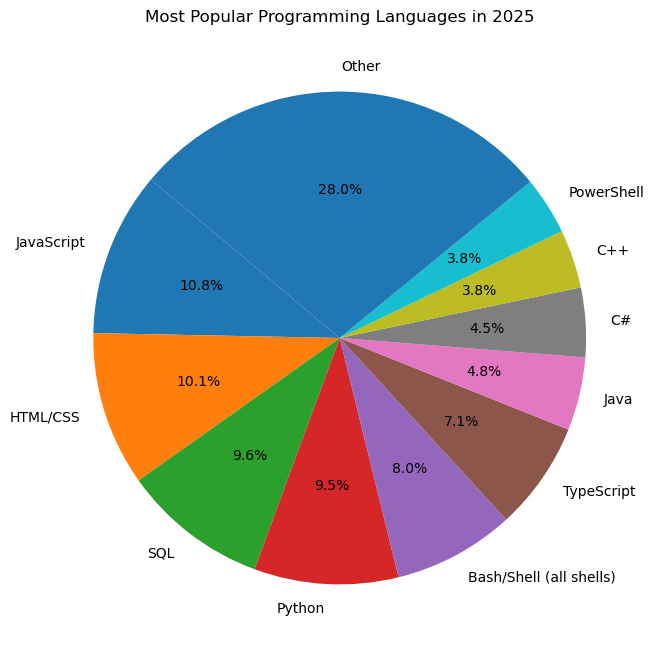

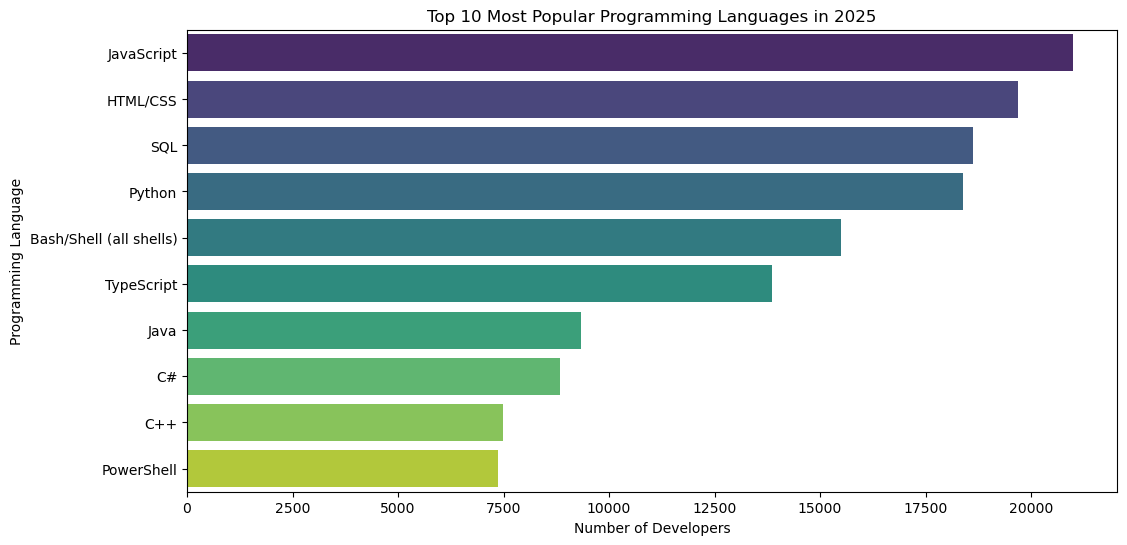

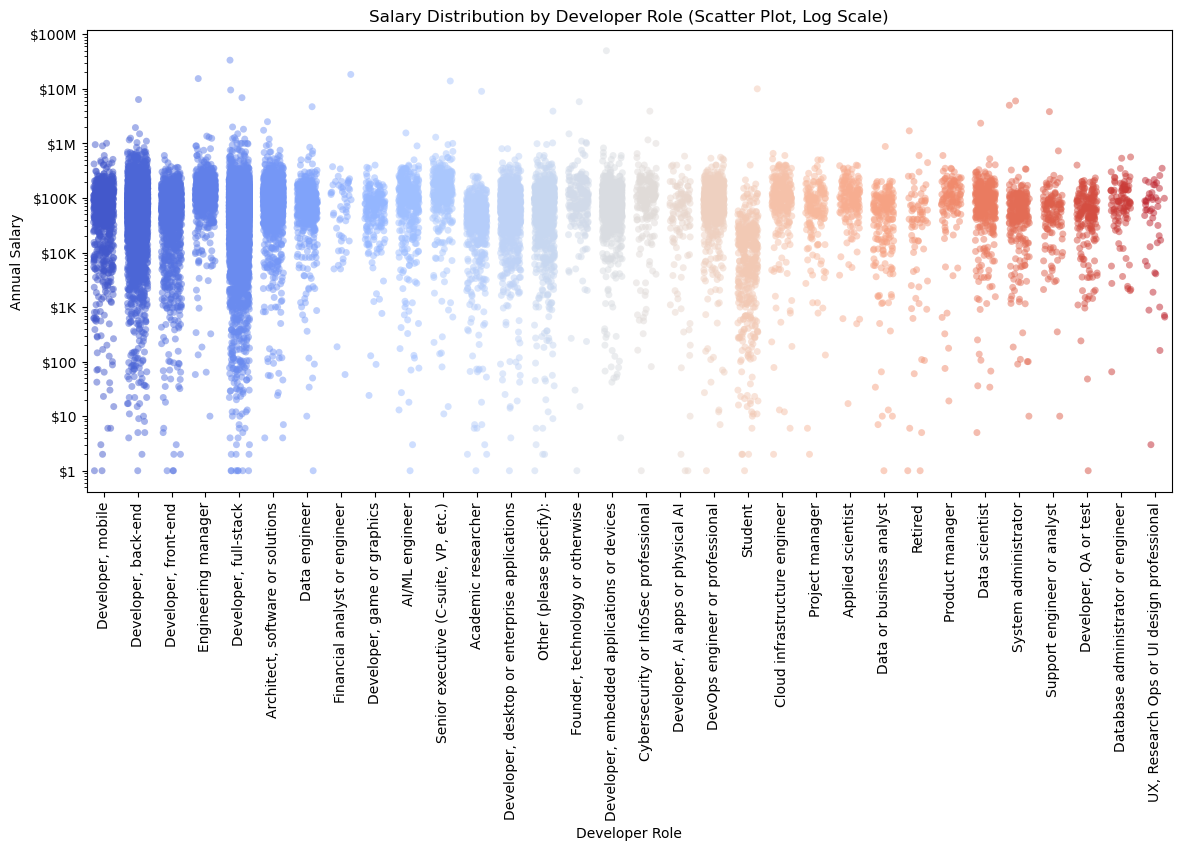

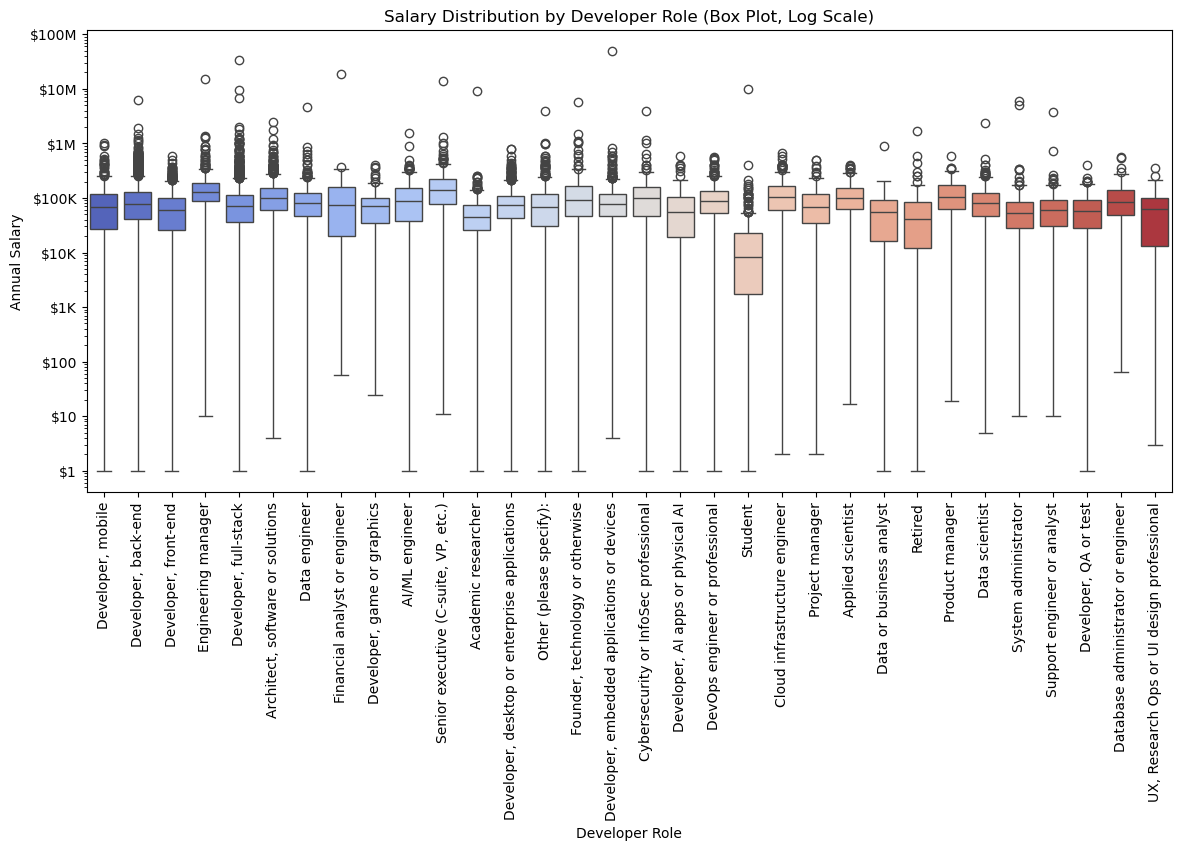

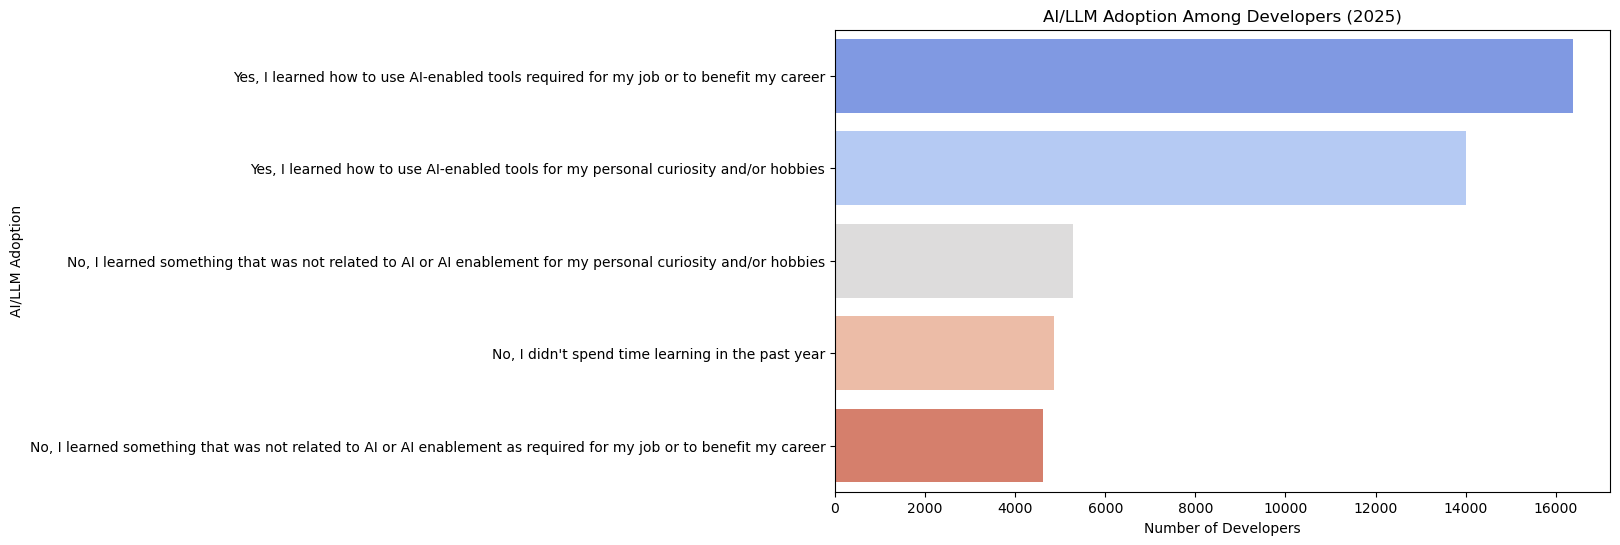

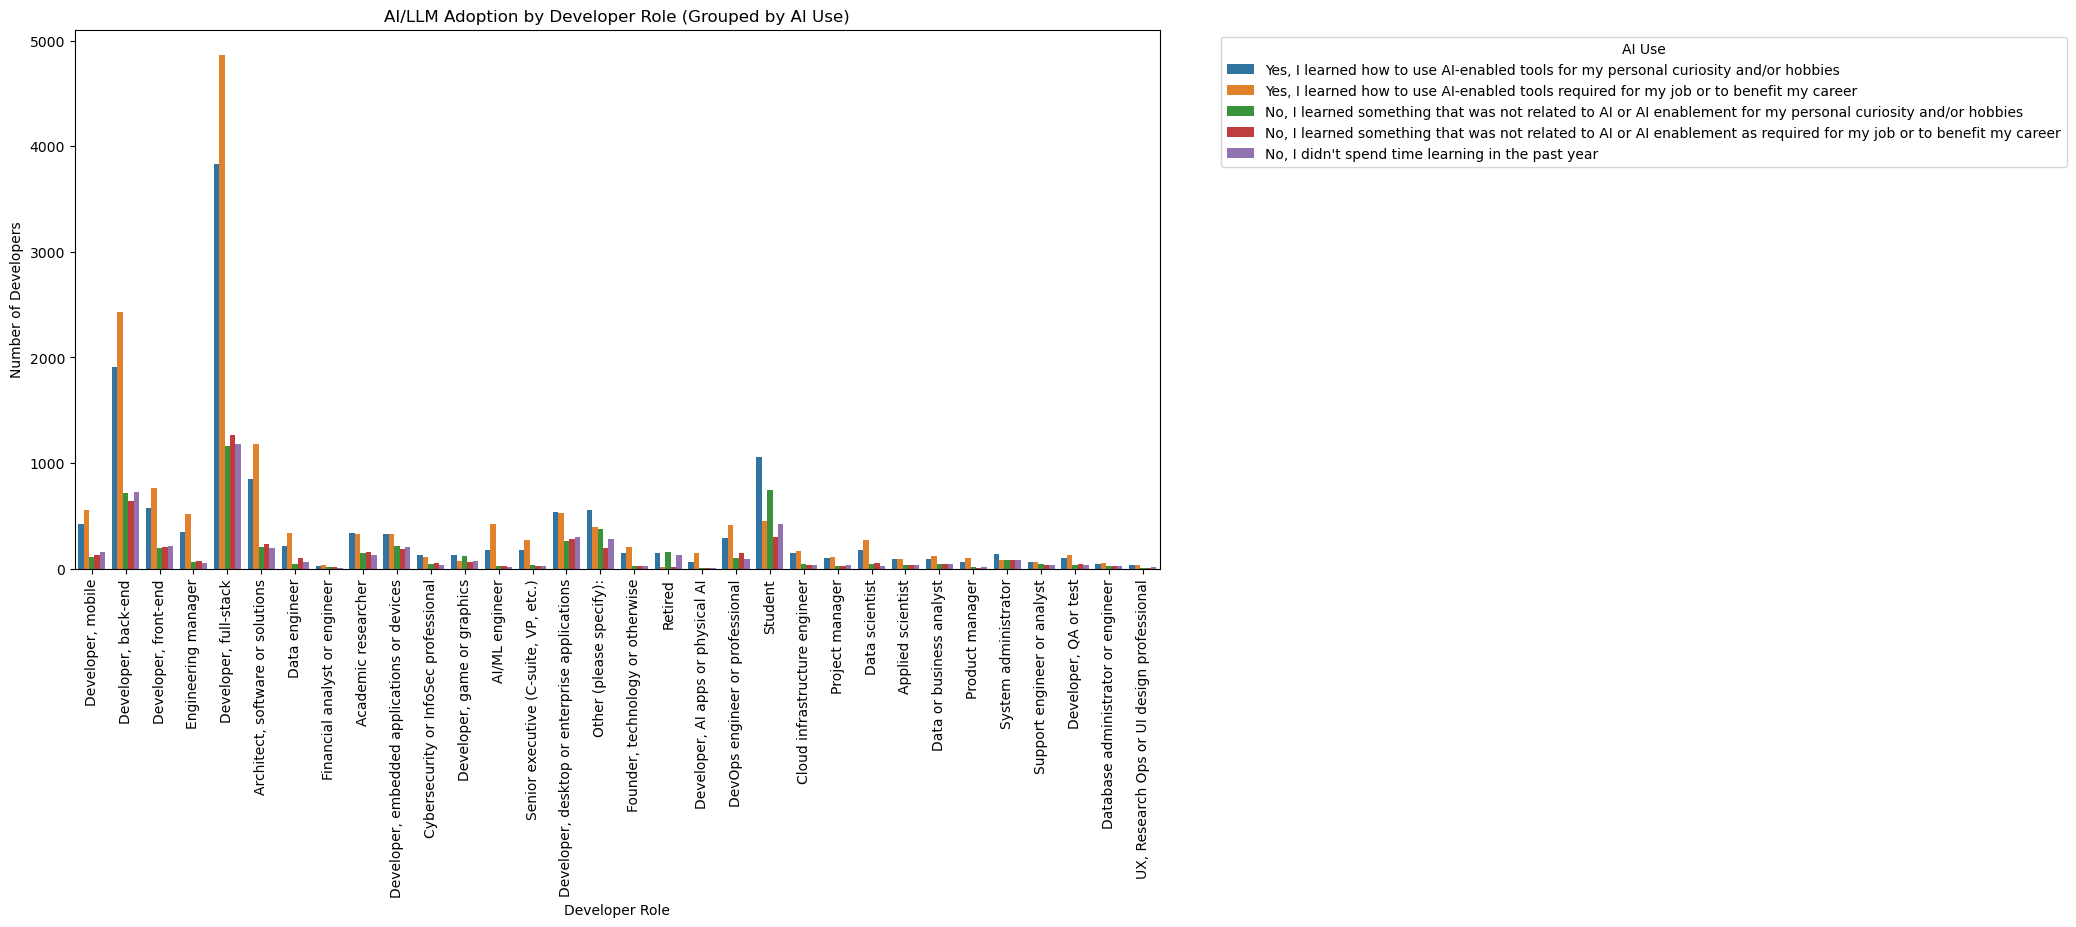

In [28]:
# 🚀 Importing some libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import glob

# Find all split CSV files
files = glob.glob("data/data/survey_results_part*.csv")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df.columns = df.columns.str.strip()

# DEBUGGER FOR JOINING CSV FILES TOGETHER
# print(df.columns)
# END OF DEBUGGER

language_col = 'LanguageHaveWorkedWith'
salary_col = 'ConvertedCompYearly'
ai_col = 'LearnCodeAI'
devtype_col = 'DevType'

# DEBUGGER FOR JOINING CSV FILES TOGETHER
# print(df.shape)
# print(df.head())
# print(df.describe())
# print(df.isnull().sum())
# print(df[language_col].value_counts().head())
# print(df[salary_col].head())
# print(df[ai_col].value_counts())
# END OF DEBUGGER

# =======================
# Question 1: What are the most popular programming languages in 2025?
# =======================

languages_series = df[language_col].dropna().str.split(';').explode()
language_counts = languages_series.value_counts()

df_salary = df[[devtype_col, salary_col]].dropna()
df_salary = df_salary.assign(
    **{devtype_col: df_salary[devtype_col].str.split(';')}).explode(devtype_col)

ai_counts = df[ai_col].value_counts()

top_languages = language_counts[:10]
other_count = language_counts[10:].sum()
top_languages['Other'] = other_count

# Primary: Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(
    top_languages,
    labels=top_languages.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Most Popular Programming Languages in 2025")
plt.show()

# Secondary: Horizontal Bar Chart
top_10_df = top_10_langs.reset_index()
top_10_df.columns = ['Language', 'Count']
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Count',
    y='Language',
    data=top_10_df,
    hue='Language',
    dodge=False,
    palette='viridis',
    legend=False
)
plt.xlabel("Number of Developers")
plt.ylabel("Programming Language")
plt.title("Top 10 Most Popular Programming Languages in 2025")
plt.show()

# =======================
# Question 2: Are certain developer roles paid more on average?
# =======================

devtype_col = 'DevType'
salary_col = 'ConvertedCompYearly'
df_salary_filtered = df_salary[df_salary[salary_col] > 0]

# Create a money formatter for log scale


def money_formatter(x, pos):
  if x >= 1_000_000:
    return f"${x/1_000_000:.0f}M"
  elif x >= 1_000:
    return f"${x/1_000:.0f}K"
  else:
    return f"${x:.0f}"


# Primary: Scatter Plot
plt.figure(figsize=(14, 6))
sns.stripplot(
    x=devtype_col,
    y=salary_col,
    data=df_salary_filtered,
    jitter=0.3,
    alpha=0.5,
    hue=devtype_col,
    dodge=False,
    palette="coolwarm",
    legend=False
)
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(money_formatter))
plt.xticks(rotation=90)
plt.ylabel("Annual Salary")
plt.xlabel("Developer Role")
plt.title("Salary Distribution by Developer Role (Scatter Plot, Log Scale)")
plt.show()

# Secondary: Box Plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    x=devtype_col,
    y=salary_col,
    data=df_salary_filtered,
    hue=devtype_col,
    dodge=False,
    palette="coolwarm",
    legend=False
)
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(money_formatter))
plt.xticks(rotation=90)
plt.ylabel("Annual Salary")
plt.xlabel("Developer Role")
plt.title("Salary Distribution by Developer Role (Box Plot, Log Scale)")
plt.show()

# =======================
# Question 3: What percentage of developers have tried AI coding assistants or LLMs?
# =======================

ai_col = 'LearnCodeAI'
ai_counts = df[ai_col].value_counts()
colors = list(plt.cm.coolwarm(np.linspace(0, 1, len(ai_counts))))

# Primary: Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=ai_counts.values,
    y=ai_counts.index,
    hue=ai_counts.index,
    dodge=False,
    legend=False,
    palette='coolwarm'
)
plt.xlabel("Number of Developers")
plt.ylabel("AI/LLM Adoption")
plt.title("AI/LLM Adoption Among Developers (2025)")
plt.show()

df_ai_role = df[[devtype_col, ai_col]].dropna()
df_ai_role = df_ai_role.assign(
    DevType=df_ai_role[devtype_col].str.split(';')).explode('DevType')

# Secondary: Stacked Bar Chart
plt.figure(figsize=(14, 7))
sns.countplot(
    x='DevType',
    hue=ai_col,
    data=df_ai_role,
)
plt.xticks(rotation=90)
plt.ylabel("Number of Developers")
plt.xlabel("Developer Role")
plt.title("AI/LLM Adoption by Developer Role (Grouped by AI Use)")
plt.legend(title="AI Use", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()